# ASH Inner Fair — 均值回归生成机制逆向工程

目标: 把 `data/raw` 里的 ASH_COATED_OSMIUM 三天挂单数据拼起来, 按 `fair_caculate.md` 重建 outer / inner fair, 然后对 inner fair 跑 `reverse_engineering_hypotheses.md` 里的诊断, 判断主办方用的是哪种生成机制 (OU / AR1+取整 / 带反射墙 RW / OU+跳 / Regime).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from scipy import stats

# CJK 字体, 避免 plot 标题 tofu
plt.rcParams['font.sans-serif'] = ['PingFang SC', 'Arial Unicode MS', 'Heiti SC', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

from utils.dataio import load_prices_wide

PRODUCT = 'ASH_COATED_OSMIUM'
MU = 10000  # 先验中心

# fair_caculate.md 参数
VOL_THRESHOLD       = 20.0
MAX_STALE_MS        = 3000
HALF_SPREAD_CONST   = 10.0
INNER_PRIOR_OFFSET  = -0.5
INNER_CONFLICT_TOL  = 0.75
INNER_OFFSET_MIN    = -2.0
INNER_OFFSET_MAX    =  1.0


## 1. 加载三天数据并拼成连续时间线

比赛里每天有 1e6 ms (1M timestamps @ step=100). 把 day=-2, -1, 0 按先后拼起来, 构造一个 `global_ts`, 方便跑全局统计, 同时保留 `day` 列以便分天验证.

In [2]:
ROUND = 1
DAYS  = [-2, -1, 0]

frames = []
for d in DAYS:
    df = load_prices_wide(ROUND, d).filter(pl.col('product') == PRODUCT)
    frames.append(df)

wide = pl.concat(frames).sort(['day', 'timestamp'])

# global_ts: 在 day 之间加一个 day_length 的偏移, 形成全局时间线 (单位=原始 timestamp)
day_len = wide.group_by('day').agg(pl.col('timestamp').max().alias('tmax'))
day_len = day_len.sort('day')
day_offsets = {}
running = 0
for row in day_len.iter_rows(named=True):
    day_offsets[row['day']] = running
    running += row['tmax'] + 100  # +step 避免边界重合

wide = wide.with_columns(
    (pl.col('timestamp') + pl.col('day').replace_strict(day_offsets, default=0)).alias('global_ts')
)
print('shape:', wide.shape)
print(wide.select(['day', 'timestamp', 'global_ts', 'bid_price_1', 'ask_price_1', 'mid_price']).head(4))
print('day offsets:', day_offsets)

shape: (30000, 18)
shape: (4, 6)
┌─────┬───────────┬───────────┬─────────────┬─────────────┬───────────┐
│ day ┆ timestamp ┆ global_ts ┆ bid_price_1 ┆ ask_price_1 ┆ mid_price │
│ --- ┆ ---       ┆ ---       ┆ ---         ┆ ---         ┆ ---       │
│ i64 ┆ i64       ┆ i64       ┆ i64         ┆ i64         ┆ f64       │
╞═════╪═══════════╪═══════════╪═════════════╪═════════════╪═══════════╡
│ -2  ┆ 0         ┆ 0         ┆ null        ┆ 10010       ┆ 10010.0   │
│ -2  ┆ 100       ┆ 100       ┆ 9992        ┆ 10008       ┆ 10000.0   │
│ -2  ┆ 200       ┆ 200       ┆ 9992        ┆ 10008       ┆ 10000.0   │
│ -2  ┆ 300       ┆ 300       ┆ 9992        ┆ 10008       ┆ 10000.0   │
└─────┴───────────┴───────────┴─────────────┴─────────────┴───────────┘
day offsets: {-2: 0, -1: 1000000, 0: 2000000}


## 1.5 验证假设均值 μ = 10000

In [3]:
# 注意: mid_price 在单侧挂单时严重偏离, 不适合做均值检验
# 需要先建 fair 后再验证 → 移到 compute_fairs 之后, 用 outer_fair 检验

## 2. 重建 outer fair / inner fair

完全按 `fair_caculate.md` 的规则:

- **outer**: 每侧在 3 档中取 `|vol| > VOL_THRESHOLD` 的最大档 (同量时 bid 取高价 / ask 取低价), 配合最多 `MAX_STALE_MS` 的跨侧缓存, 单侧存在时用 `HALF_SPREAD_CONST` 推断另一侧再取中点.
- **inner**: 以 `outer - 0.5` 为 baseline, 检查 bid1 / ask1 是否落在 `[baseline+0.5, baseline+3.5]` 或 `[baseline-3.5, baseline-0.5]` 做吸附; 两侧冲突 > 0.75 时退化到 baseline; 最后 clip + 量化到 0.5 网格.

In [4]:
def pick_side_price(px1, v1, px2, v2, px3, v3, side):
    """返回该侧通过 VOL_THRESHOLD 过滤后的最大成交量档价格; 没有则 None."""
    cands = []
    for px, v in [(px1, v1), (px2, v2), (px3, v3)]:
        if px is None or v is None:
            continue
        if abs(v) > VOL_THRESHOLD:
            cands.append((px, abs(v)))
    if not cands:
        return None
    max_v = max(c[1] for c in cands)
    top = [c[0] for c in cands if c[1] == max_v]
    return max(top) if side == 'bid' else min(top)


def compute_fairs(df: pl.DataFrame) -> pl.DataFrame:
    rows = df.sort('global_ts').to_dicts()
    last_bid = last_ask = None
    last_bid_ts = last_ask_ts = None
    last_outer = None

    outer_list = []
    inner_list = []
    bid_obs_list = []
    ask_obs_list = []

    for r in rows:
        ts = r['global_ts']
        bid_obs = pick_side_price(r['bid_price_1'], r['bid_volume_1'],
                                  r['bid_price_2'], r['bid_volume_2'],
                                  r['bid_price_3'], r['bid_volume_3'], 'bid')
        ask_obs = pick_side_price(r['ask_price_1'], r['ask_volume_1'],
                                  r['ask_price_2'], r['ask_volume_2'],
                                  r['ask_price_3'], r['ask_volume_3'], 'ask')
        if bid_obs is not None:
            last_bid, last_bid_ts = bid_obs, ts
        if ask_obs is not None:
            last_ask, last_ask_ts = ask_obs, ts

        use_bid = bid_obs if bid_obs is not None else (
            last_bid if last_bid is not None and (ts - last_bid_ts) <= MAX_STALE_MS else None)
        use_ask = ask_obs if ask_obs is not None else (
            last_ask if last_ask is not None and (ts - last_ask_ts) <= MAX_STALE_MS else None)

        if use_bid is not None and use_ask is not None:
            outer = (use_bid + use_ask) / 2
        elif use_ask is not None:
            outer = (use_ask - 2 * HALF_SPREAD_CONST + use_ask) / 2
        elif use_bid is not None:
            outer = (use_bid + use_bid + 2 * HALF_SPREAD_CONST) / 2
        elif r['mid_price'] is not None:
            outer = r['mid_price']
        else:
            outer = last_outer
        last_outer = outer

        # inner
        inner = None
        if outer is not None:
            baseline = outer + INNER_PRIOR_OFFSET
            offsets = []
            for px in [r['bid_price_1'], r['ask_price_1']]:
                if px is None:
                    continue
                norm = px - baseline
                if 0.5 <= norm <= 3.5:   # 吸附到 +2
                    offsets.append(px - 2 - outer)
                elif -3.5 <= norm <= -0.5:  # 吸附到 -2
                    offsets.append(px + 2 - outer)

            if not offsets:
                inner_off = INNER_PRIOR_OFFSET
            elif len(offsets) >= 2 and abs(offsets[0] - offsets[1]) > INNER_CONFLICT_TOL:
                inner_off = INNER_PRIOR_OFFSET
            else:
                # 绝对值最小
                inner_off = min(offsets, key=abs)

            inner_off = max(INNER_OFFSET_MIN, min(INNER_OFFSET_MAX, inner_off))
            inner_off = round(inner_off * 2) / 2
            inner = outer + inner_off

        outer_list.append(outer)
        inner_list.append(inner)
        bid_obs_list.append(bid_obs)
        ask_obs_list.append(ask_obs)

    return df.sort('global_ts').with_columns([
        pl.Series('outer_fair', outer_list, dtype=pl.Float64),
        pl.Series('inner_fair', inner_list, dtype=pl.Float64),
        pl.Series('bid_obs', bid_obs_list, dtype=pl.Float64),
        pl.Series('ask_obs', ask_obs_list, dtype=pl.Float64),
    ])


fair = compute_fairs(wide)
fair = fair.filter(pl.col('inner_fair').is_not_null())
print('有效样本:', fair.height)
print(fair.select(['day', 'timestamp', 'outer_fair', 'inner_fair']).head())

有效样本: 30000
shape: (5, 4)
┌─────┬───────────┬────────────┬────────────┐
│ day ┆ timestamp ┆ outer_fair ┆ inner_fair │
│ --- ┆ ---       ┆ ---        ┆ ---        │
│ i64 ┆ i64       ┆ f64        ┆ f64        │
╞═════╪═══════════╪════════════╪════════════╡
│ -2  ┆ 0         ┆ 10000.0    ┆ 9999.5     │
│ -2  ┆ 100       ┆ 10000.0    ┆ 9999.5     │
│ -2  ┆ 200       ┆ 9999.5     ┆ 9999.0     │
│ -2  ┆ 300       ┆ 9999.5     ┆ 9999.0     │
│ -2  ┆ 400       ┆ 9999.5     ┆ 9999.0     │
└─────┴───────────┴────────────┴────────────┘


## 2.5 验证假设均值 μ = 10000

用 outer_fair (双侧 / 缓存推断后的估计) 和 inner_fair 分别检验, 避免 mid_price 单侧污染.

=== outer_fair ===
  mean=10000.2115  median=10000.5  std=4.6926
  t-test vs 10000:  t=+7.808  p=0.0000
  day -2: mean=9998.1503  std=4.5484
  day -1: mean=10000.8442  std=3.6193
  day +0: mean=10001.6402  std=5.0581

=== inner_fair ===
  mean=9999.7117  median=10000.0  std=4.6935
  t-test vs 10000:  t=-10.640  p=0.0000
  day -2: mean=9997.6500  std=4.5490
  day -1: mean=10000.3446  std=3.6204
  day +0: mean=10001.1404  std=5.0591



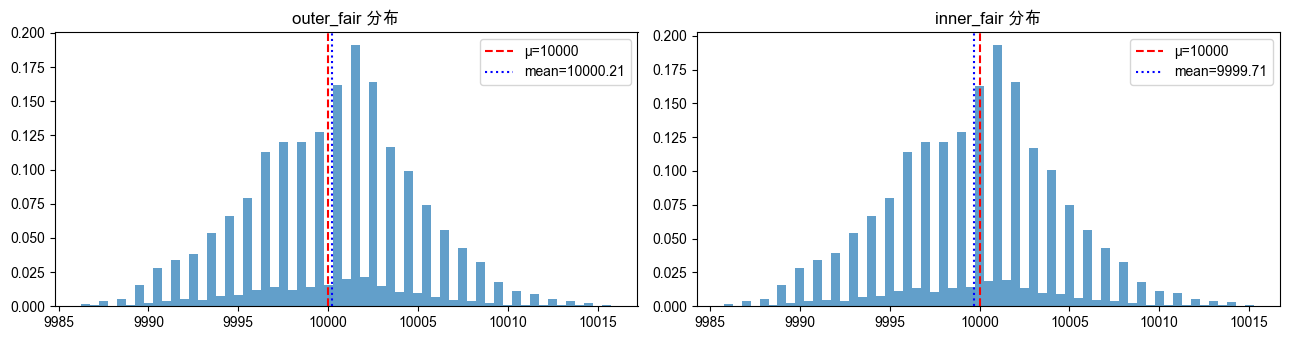

In [5]:
from scipy.stats import ttest_1samp

for col in ['outer_fair', 'inner_fair']:
    v = fair[col].drop_nulls().to_numpy()
    t_stat, p_val = ttest_1samp(v, 10000)
    print(f'=== {col} ===')
    print(f'  mean={v.mean():.4f}  median={np.median(v):.1f}  std={v.std():.4f}')
    print(f'  t-test vs 10000:  t={t_stat:+.3f}  p={p_val:.4f}')
    for d in DAYS:
        sub = fair.filter(pl.col('day') == d)[col].drop_nulls().to_numpy()
        print(f'  day {d:+d}: mean={sub.mean():.4f}  std={sub.std():.4f}')
    print()

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
for ax, col in zip(axes, ['outer_fair', 'inner_fair']):
    v = fair[col].drop_nulls().to_numpy()
    ax.hist(v, bins=np.arange(v.min()-0.25, v.max()+0.75, 0.5), density=True, alpha=0.7)
    ax.axvline(10000, color='r', ls='--', lw=1.5, label='μ=10000')
    ax.axvline(v.mean(), color='blue', ls=':', lw=1.5, label=f'mean={v.mean():.2f}')
    ax.set_title(f'{col} 分布'); ax.legend()
plt.tight_layout(); plt.show()

## 3. 时间序列总览

先肉眼看 inner fair 在 10000 附近的行为, 三天分色绘制.

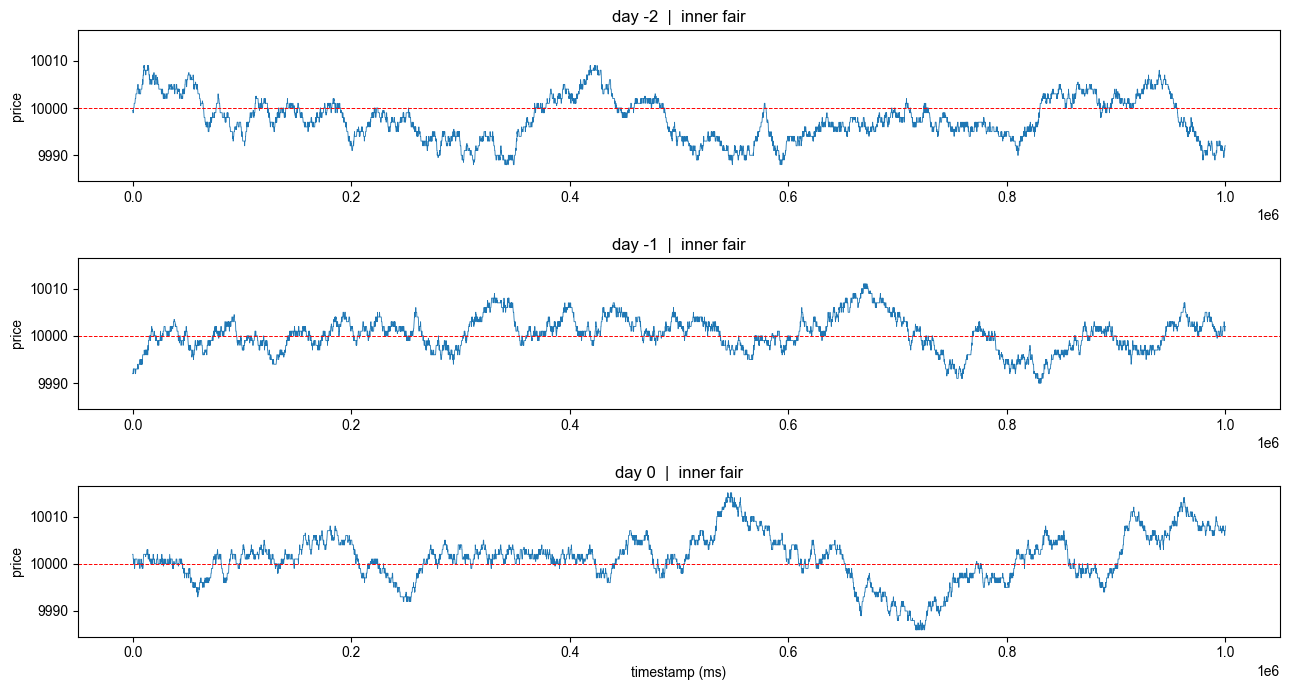

mean=9999.712  std=4.694  min=9986.0  max=10015.0  median=10000.0


In [6]:
pdf = fair.to_pandas()

fig, axes = plt.subplots(3, 1, figsize=(13, 7), sharey=True)
for ax, d in zip(axes, DAYS):
    sub = pdf[pdf['day'] == d]
    ax.plot(sub['timestamp'], sub['inner_fair'], lw=0.6)
    ax.axhline(MU, color='red', lw=0.7, ls='--')
    ax.set_title(f'day {d}  |  inner fair')
    ax.set_ylabel('price')
axes[-1].set_xlabel('timestamp (ms)')
plt.tight_layout(); plt.show()

p = pdf['inner_fair'].to_numpy()
print(f'mean={p.mean():.3f}  std={p.std():.3f}  min={p.min()}  max={p.max()}  median={np.median(p)}')

## 4. 诊断 1 — E[Δp | p] vs p

- 线性过零点 → OU / AR(1) 类 (假设 A / B / D / E)
- 内部平坦 + 边界突然翻折 → 反射墙 (假设 C)
- 斜率取负 = θ

线性拟合 Δp = -0.00415·(p-μ) + -0.00092   θ̂ = 0.00415   R²=0.0021


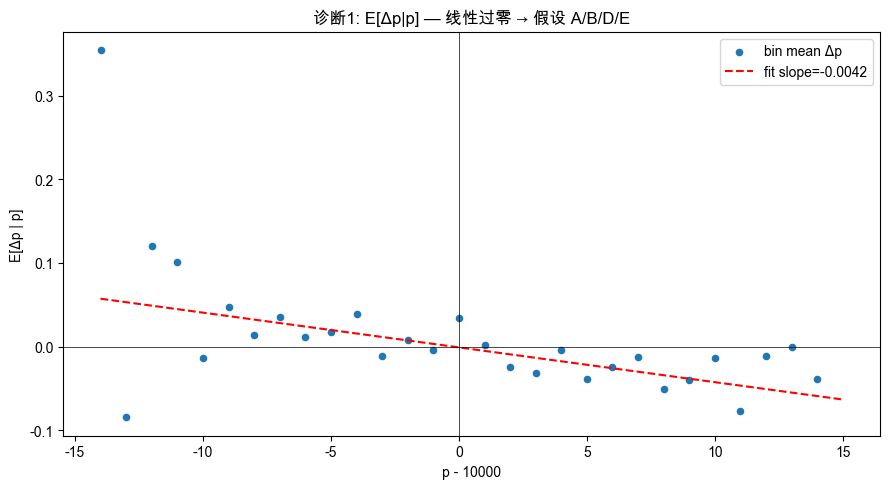

In [7]:
p   = pdf['inner_fair'].to_numpy()
dp  = np.diff(p)
dev = (p - MU)[:-1]

# 离散 bin 平均
bins = np.arange(dev.min() - 0.5, dev.max() + 1.5, 1.0)
centers = (bins[:-1] + bins[1:]) / 2
bin_ix = np.digitize(dev, bins) - 1
nbin = len(centers)
mean_dp = np.full(nbin, np.nan)
for i in range(nbin):
    sel = bin_ix == i
    if sel.sum() > 20:
        mean_dp[i] = dp[sel].mean()

slope, intercept, r, _, _ = stats.linregress(dev, dp)
theta_hat = -slope
print(f'线性拟合 Δp = {slope:.5f}·(p-μ) + {intercept:.5f}   θ̂ = {theta_hat:.5f}   R²={r**2:.4f}')

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(centers, mean_dp, s=20, label='bin mean Δp')
xs = np.linspace(dev.min(), dev.max(), 200)
ax.plot(xs, slope * xs + intercept, 'r--', label=f'fit slope={slope:.4f}')
ax.axhline(0, color='k', lw=0.5)
ax.axvline(0, color='k', lw=0.5)
ax.set_xlabel('p - 10000'); ax.set_ylabel('E[Δp | p]')
ax.set_title('诊断1: E[Δp|p] — 线性过零 → 假设 A/B/D/E'); ax.legend()
plt.tight_layout(); plt.show()


## 5. 诊断 2 — Δp 分布 & Δp=0 占比

- 连续 OU (假设 A) 理论上 P(Δp = 0) ≈ 0, 分布为高斯.
- AR(1)+round (假设 B) 会在 0 和 ±1 出现尖峰, 且 Δp=0 比例大幅高于高斯.
- OU+跳 (假设 D) 会出现重尾.

σ(Δp) = 0.4304
P(Δp = 0)  实测 = 0.7157
连续 OU 预测 P(|Δp|<0.5) ≈ 0.7546
峰度(超额) = 2.000   偏度 = 0.011


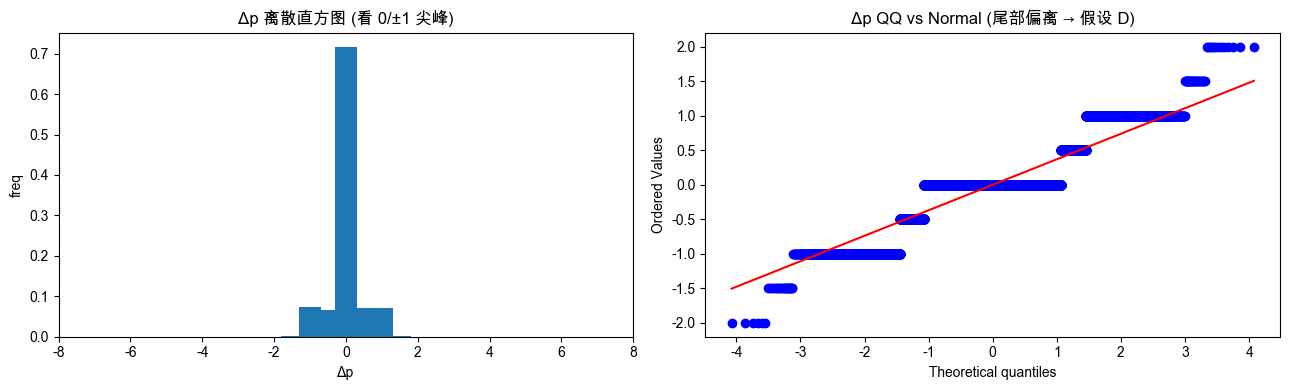

In [8]:
frac_zero = (dp == 0).mean()
sigma_dp  = dp.std()
kurt      = stats.kurtosis(dp, fisher=True)
skewv     = stats.skew(dp)
ou_zero_pred = 2 * stats.norm.cdf(0.5 / sigma_dp) - 1  # 连续 OU 下落到 (−0.5,0.5] 的概率上界

print(f'σ(Δp) = {sigma_dp:.4f}')
print(f'P(Δp = 0)  实测 = {frac_zero:.4f}')
print(f'连续 OU 预测 P(|Δp|<0.5) ≈ {ou_zero_pred:.4f}')
print(f'峰度(超额) = {kurt:.3f}   偏度 = {skewv:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
vals, cnts = np.unique(dp, return_counts=True)
axes[0].bar(vals, cnts / cnts.sum(), width=0.6)
axes[0].set_xlim(-8, 8)
axes[0].set_title('Δp 离散直方图 (看 0/±1 尖峰)')
axes[0].set_xlabel('Δp'); axes[0].set_ylabel('freq')

# QQ plot
stats.probplot(dp, dist='norm', plot=axes[1])
axes[1].set_title('Δp QQ vs Normal (尾部偏离 → 假设 D)')
plt.tight_layout(); plt.show()

## 6. 诊断 3 — ACF of Δp (应为白噪声) 和 p (应指数衰减)

- p 的 ACF 指数衰减速率 = θ, 与诊断 1 应该一致.
- Δp 的 ACF 若存在显著 lag-1 负相关 → 过度回复 (AR(1)) 或取整扰动.

ACF 估 θ = 0.00423  (对照诊断1 θ̂ = 0.00415)


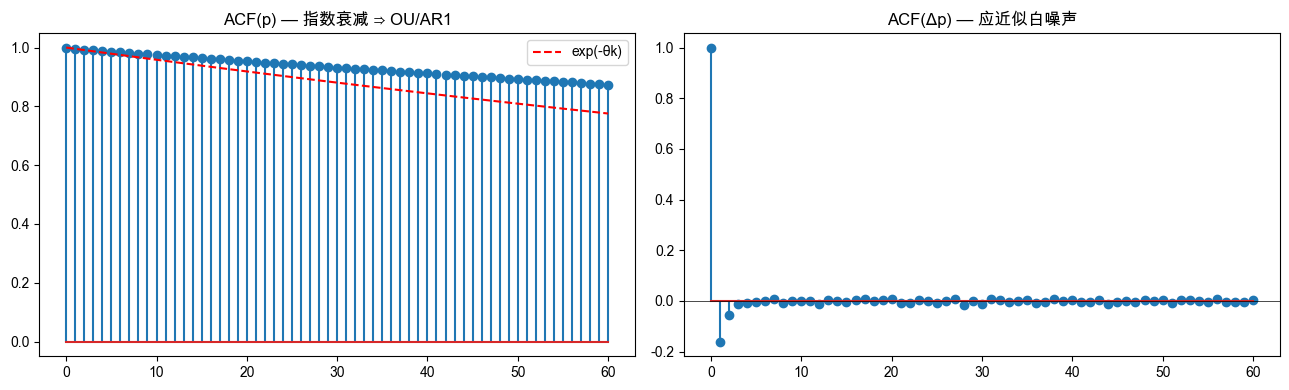

In [9]:
def acf(x, nlags):
    x = x - x.mean()
    var = (x * x).mean()
    return np.array([(x[:len(x) - k] * x[k:]).mean() / var for k in range(nlags + 1)])

NLAG = 60
acf_p  = acf(p, NLAG)
acf_dp = acf(dp, NLAG)

# 从 p 的 ACF 估 θ: a(k) ≈ exp(-θ·k) → θ ≈ -ln(a(1))
theta_from_acf = -np.log(max(acf_p[1], 1e-9))
print(f'ACF 估 θ = {theta_from_acf:.5f}  (对照诊断1 θ̂ = {theta_hat:.5f})')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].stem(range(NLAG + 1), acf_p)
axes[0].plot(range(NLAG + 1), np.exp(-theta_from_acf * np.arange(NLAG + 1)), 'r--', label='exp(-θk)')
axes[0].set_title('ACF(p) — 指数衰减 ⇒ OU/AR1'); axes[0].legend()
axes[1].stem(range(NLAG + 1), acf_dp)
axes[1].axhline(0, color='k', lw=0.5)
axes[1].set_title('ACF(Δp) — 应近似白噪声')
plt.tight_layout(); plt.show()

## 7. 诊断 4 — OU 拟合残差 & 稳态分布形状

拟合 p(t+1) - p(t) = -θ(p(t) - μ) + ε, 残差应为白噪声高斯. 稳态分布形状: 钟形 → OU; 矩形/梯形 → 反射墙; 长尾 → OU+跳.

σ_ε(残差) = 0.4300
σ_p 观测 = 4.6935   OU 理论 = 4.7227
残差峰度 = 1.992   残差偏度 = 0.012


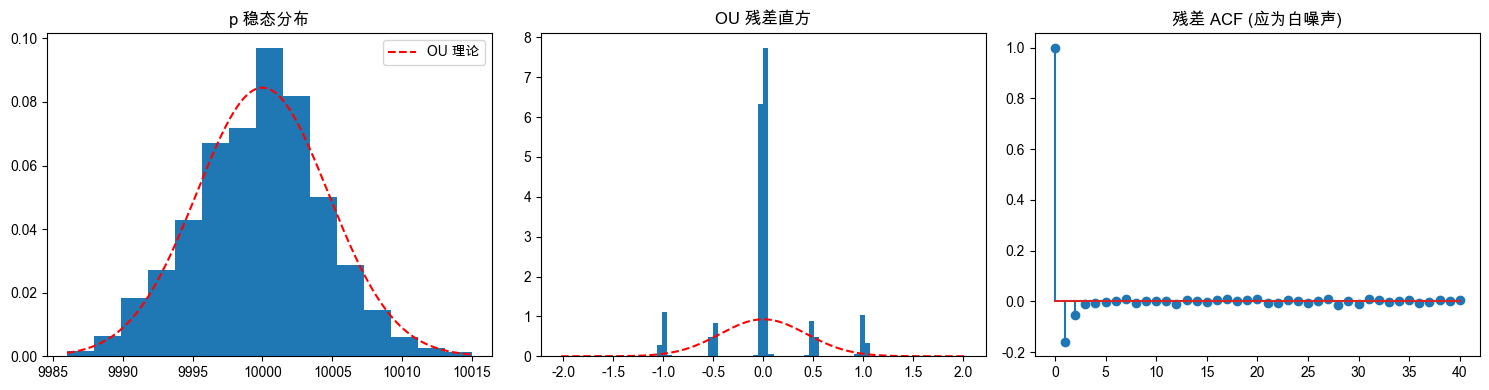

In [10]:
resid = dp - (intercept + slope * dev)
sigma_eps = resid.std()
# 稳态理论 σ_p = σ_ε / sqrt(1 - (1-θ)^2) = σ_ε / sqrt(2θ - θ^2)
if theta_hat > 0:
    sigma_p_pred = sigma_eps / np.sqrt(max(2 * theta_hat - theta_hat ** 2, 1e-9))
else:
    sigma_p_pred = np.nan
sigma_p_obs = p.std()
print(f'σ_ε(残差) = {sigma_eps:.4f}')
print(f'σ_p 观测 = {sigma_p_obs:.4f}   OU 理论 = {sigma_p_pred:.4f}')
print(f'残差峰度 = {stats.kurtosis(resid):.3f}   残差偏度 = {stats.skew(resid):.3f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
#axes[0].hist(p, bins=np.arange(p.min() - 0.25, p.max() + 0.75, 0.5), density=True)
axes[0].hist(p, bins=15, density=True)
if np.isfinite(sigma_p_pred):
    xs = np.linspace(p.min(), p.max(), 200)
    axes[0].plot(xs, stats.norm.pdf(xs, MU, sigma_p_pred), 'r--', label='OU 理论')
    axes[0].legend()
axes[0].set_title('p 稳态分布')

axes[1].hist(resid, bins=80, density=True)
xs = np.linspace(resid.min(), resid.max(), 200)
axes[1].plot(xs, stats.norm.pdf(xs, 0, sigma_eps), 'r--')
axes[1].set_title('OU 残差直方')

acf_res = acf(resid, 40)
axes[2].stem(range(41), acf_res)
axes[2].set_title('残差 ACF (应为白噪声)')
plt.tight_layout(); plt.show()

## 8. 诊断 5 — 跳跃检测 (假设 D)

标记 |Δp| > 3σ_ε 的点, 看分布和间隔是否符合 Poisson.

跳跃阈值 |Δp| > 1.290   候选跳跃数 = 67   比例 = 0.00223


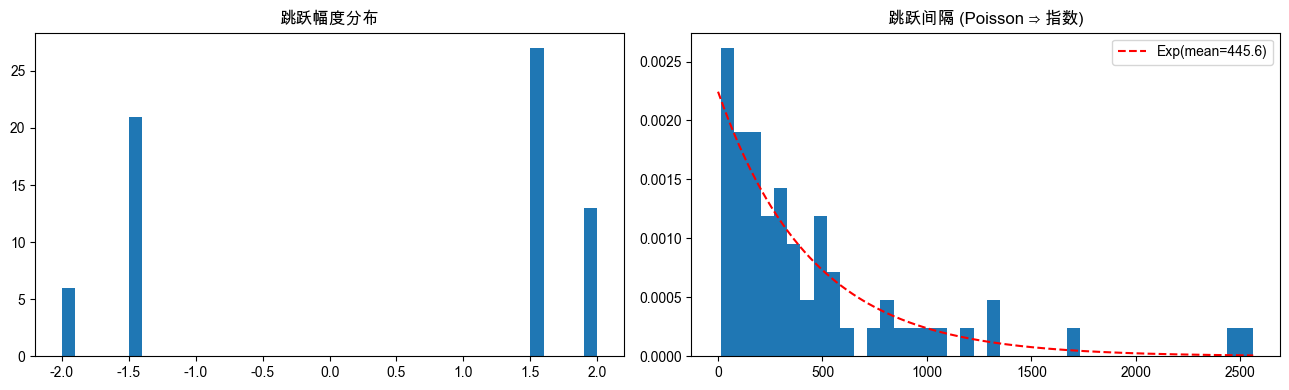

In [11]:
thr = 3 * sigma_eps
jump_ix = np.where(np.abs(dp) > thr)[0]
print(f'跳跃阈值 |Δp| > {thr:.3f}   候选跳跃数 = {len(jump_ix)}   比例 = {len(jump_ix)/len(dp):.5f}')
if len(jump_ix) > 5:
    gaps = np.diff(jump_ix)
    # 指数拟合
    mean_gap = gaps.mean()
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].hist(dp[jump_ix], bins=40)
    axes[0].set_title('跳跃幅度分布')
    axes[1].hist(gaps, bins=40, density=True)
    xs = np.linspace(0, gaps.max(), 200)
    axes[1].plot(xs, (1 / mean_gap) * np.exp(-xs / mean_gap), 'r--', label=f'Exp(mean={mean_gap:.1f})')
    axes[1].legend(); axes[1].set_title('跳跃间隔 (Poisson ⇒ 指数)')
    plt.tight_layout(); plt.show()

## 9. 诊断 6 — 滚动波动率 (假设 E regime)

滚动 window σ(Δp) 的直方图: 单峰 ⇒ 单 regime, 双峰 ⇒ 存在切换.

滚动 σ: mean=0.431 std=0.008 min=0.415 max=0.446


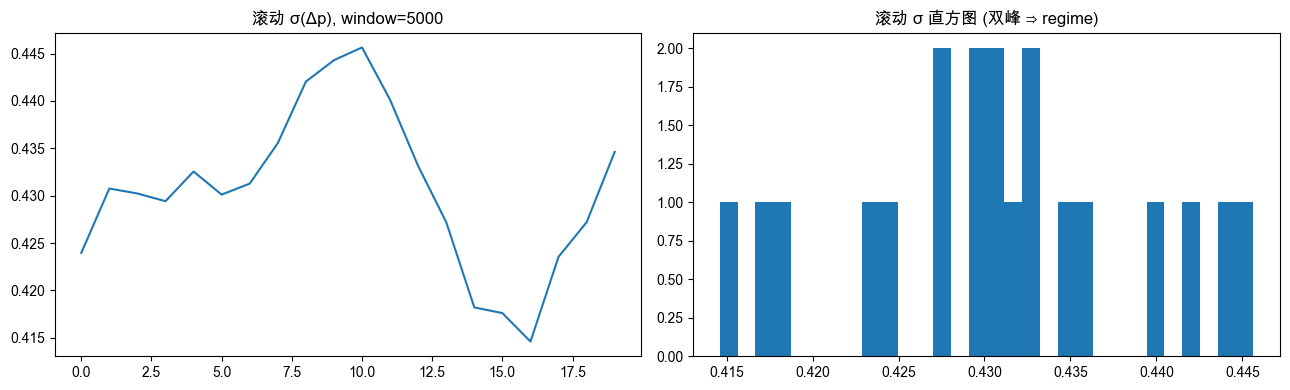

In [12]:
W = 5000
s = pdf['inner_fair'].to_numpy()
dps = np.diff(s)
roll = np.array([dps[i:i+W].std() for i in range(0, len(dps) - W, W // 4)])
print(f'滚动 σ: mean={roll.mean():.3f} std={roll.std():.3f} min={roll.min():.3f} max={roll.max():.3f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(roll); axes[0].set_title(f'滚动 σ(Δp), window={W}')
axes[1].hist(roll, bins=30)
axes[1].set_title('滚动 σ 直方图 (双峰 ⇒ regime)')
plt.tight_layout(); plt.show()

## 10. 结论模板

按上面的 6 个诊断填:

1. **E[Δp|p] 形状** →  (线性 / 边界翻折 / 平坦)  ⇒  θ̂ = ___
2. **Δp 离散峰** →  P(Δp=0) = ___  vs OU 预测 ___  ⇒  (是 / 否) 存在取整
3. **p 的 ACF** 指数衰减速率 ⇒  θ_ACF = ___  (与 θ̂ 是否一致)
4. **OU 残差** 正态? ACF 白噪声?  ⇒  (A/B 合格 / 需 D / 需 E)
5. **跳跃检测**  λ̂ = ___  ⇒  是否需要假设 D
6. **滚动 σ**  单峰/双峰  ⇒  是否需要假设 E

综合判断最可能的生成机制.

## 11. 诊断 7 — inner fair 的波动率聚集

核心思路：

- 先把价格序列转为收益序列 `r_t = p_t - p_{t-1}`.
- 若存在波动率聚集, 则 `|r_t|` 或 `r_t^2` 会有显著正自相关。
- 统计上常用两类检验：
  - `ACF(|r_t|)` / `ACF(r_t^2)`
  - Ljung-Box 对 `|r_t|` 和 `r_t^2` 的联合自相关检验。
- 本数据有较多 `r_t=0`（价格栅格 + 挂单不动），所以同时报告“全样本”和“仅非零收益”结果，避免被 0 稀释。

n(price)=30000, n(ret)=29999, zero ratio=0.7157, n(non-zero)=8529

ACF(|r|)  全样本:
lag  1:  0.0520
lag  5:  0.0047
lag 10:  0.0006
lag 20: -0.0051
ACF(r^2) 全样本:
lag  1:  0.0289
lag  5:  0.0026
lag 10:  0.0006
lag 20: -0.0047

ACF(|r|)  非零收益:
lag  1:  0.2886
lag  5: -0.0008
lag 10: -0.0122
lag 20: -0.0028
ACF(r^2) 非零收益:
lag  1:  0.2482
lag  5: -0.0008
lag 10: -0.0112
lag 20: -0.0003

Ljung-Box on |r| (全样本):
      lb_stat     lb_pvalue
1   81.083800  2.163462e-19
5   86.634825  3.418176e-17
10  90.373662  4.515709e-15
20  93.927339  1.513149e-11

Ljung-Box on r^2 (全样本):
      lb_stat     lb_pvalue
1   25.114441  5.402673e-07
5   26.375474  7.545071e-05
10  27.665555  2.041637e-03
20  30.546250  6.147283e-02

Ljung-Box on |r| (非零收益):
       lb_stat      lb_pvalue
1   710.584060  1.493328e-156
5   818.571612  1.110267e-174
10  821.465975  5.002612e-170
20  836.692566  2.280342e-164

Ljung-Box on r^2 (非零收益):
       lb_stat      lb_pvalue
1   525.426637  2.792009e-116
5   605.862113  1.094566

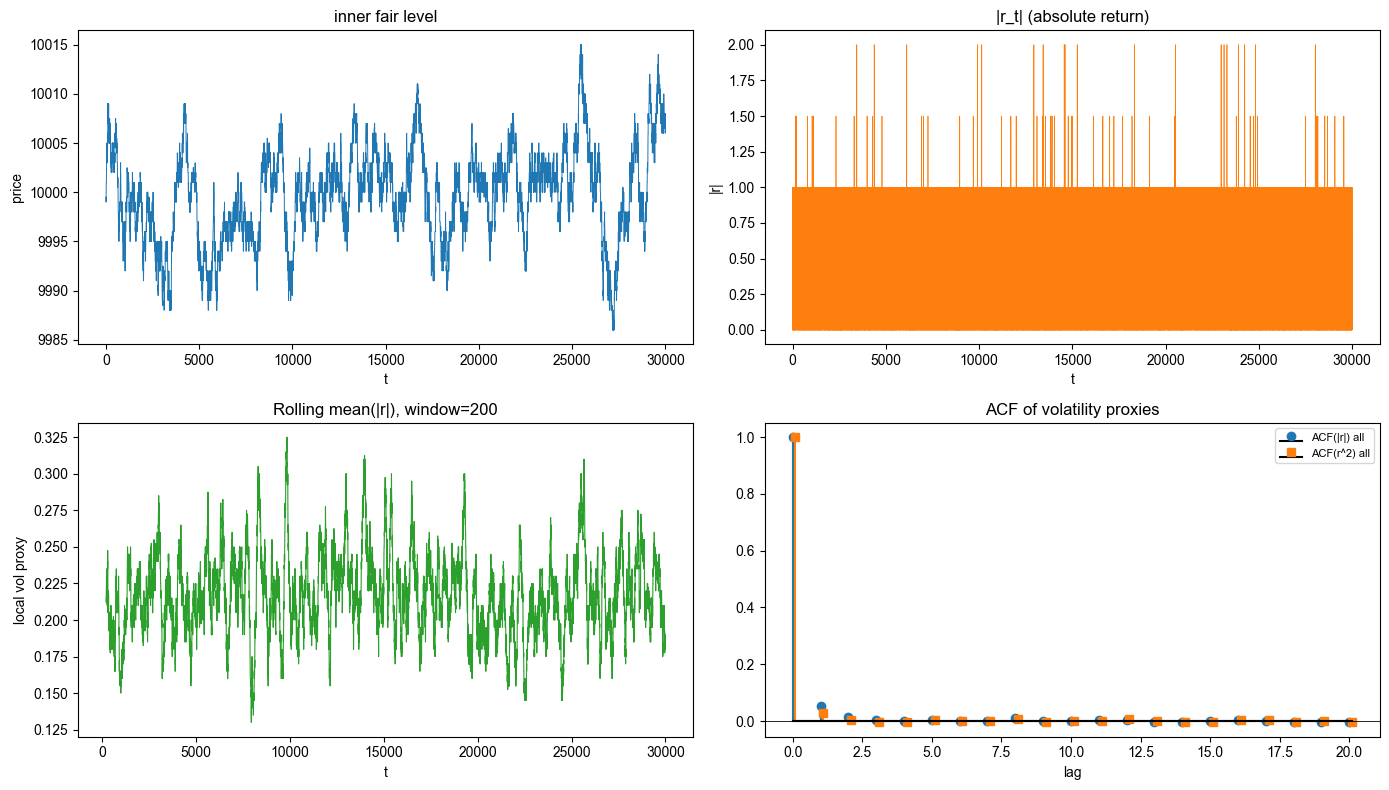


[判定]
inner fair 存在明显波动率聚集（事件时间下证据很强）。


In [13]:
from statsmodels.tsa.stattools import acf as sm_acf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

# 1) 构造收益
pdf_local = fair.select(['global_ts', 'inner_fair']).to_pandas().sort_values('global_ts')
p = pdf_local['inner_fair'].astype(float).reset_index(drop=True)
r = p.diff().dropna()
abs_r = r.abs()
sq_r = r.pow(2)
r_nz = r[r != 0]
abs_r_nz = r_nz.abs()
sq_r_nz = r_nz.pow(2)

print(f'n(price)={len(p)}, n(ret)={len(r)}, zero ratio={(r==0).mean():.4f}, n(non-zero)={len(r_nz)}')

# 2) ACF
LAGS = [1, 5, 10, 20]
acf_abs = sm_acf(abs_r, nlags=max(LAGS), fft=True)
acf_sq = sm_acf(sq_r, nlags=max(LAGS), fft=True)
acf_abs_nz = sm_acf(abs_r_nz, nlags=max(LAGS), fft=True)
acf_sq_nz = sm_acf(sq_r_nz, nlags=max(LAGS), fft=True)

print('\nACF(|r|)  全样本:')
for k in LAGS:
    print(f'lag {k:>2}: {acf_abs[k]: .4f}')
print('ACF(r^2) 全样本:')
for k in LAGS:
    print(f'lag {k:>2}: {acf_sq[k]: .4f}')

print('\nACF(|r|)  非零收益:')
for k in LAGS:
    print(f'lag {k:>2}: {acf_abs_nz[k]: .4f}')
print('ACF(r^2) 非零收益:')
for k in LAGS:
    print(f'lag {k:>2}: {acf_sq_nz[k]: .4f}')

# 3) Ljung-Box
lb_abs = acorr_ljungbox(abs_r, lags=LAGS, return_df=True)
lb_sq = acorr_ljungbox(sq_r, lags=LAGS, return_df=True)
lb_abs_nz = acorr_ljungbox(abs_r_nz, lags=LAGS, return_df=True)
lb_sq_nz = acorr_ljungbox(sq_r_nz, lags=LAGS, return_df=True)

print('\nLjung-Box on |r| (全样本):')
print(lb_abs)
print('\nLjung-Box on r^2 (全样本):')
print(lb_sq)
print('\nLjung-Box on |r| (非零收益):')
print(lb_abs_nz)
print('\nLjung-Box on r^2 (非零收益):')
print(lb_sq_nz)

# 4) ARCH-LM（补充）
arch_lm = het_arch(r, nlags=10)
print('\nARCH-LM on r (10 lags):')
print(f'LM stat={arch_lm[0]:.4f}, p={arch_lm[1]:.6f}, F stat={arch_lm[2]:.4f}, p={arch_lm[3]:.6f}')

# 5) 可视化
roll_w = 200
rv = abs_r.rolling(roll_w, min_periods=roll_w).mean()  # 简单局部波动率 proxy

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# 图1: 价格 + |r|
axes[0, 0].plot(p.values, lw=0.7, label='inner fair')
axes[0, 0].set_title('inner fair level')
axes[0, 0].set_xlabel('t')
axes[0, 0].set_ylabel('price')

axes[0, 1].plot(abs_r.values, lw=0.5, color='tab:orange')
axes[0, 1].set_title('|r_t| (absolute return)')
axes[0, 1].set_xlabel('t')
axes[0, 1].set_ylabel('|r|')

# 图2: 局部波动率
axes[1, 0].plot(rv.values, lw=0.8, color='tab:green')
axes[1, 0].set_title(f'Rolling mean(|r|), window={roll_w}')
axes[1, 0].set_xlabel('t')
axes[1, 0].set_ylabel('local vol proxy')

# 图3: ACF 比较
lags_plot = np.arange(0, max(LAGS)+1)
axes[1, 1].stem(lags_plot, acf_abs[:max(LAGS)+1], linefmt='C0-', markerfmt='C0o', basefmt='k-', label='ACF(|r|) all')
axes[1, 1].stem(lags_plot + 0.1, acf_sq[:max(LAGS)+1], linefmt='C1-', markerfmt='C1s', basefmt='k-', label='ACF(r^2) all')
axes[1, 1].axhline(0, color='k', lw=0.6)
axes[1, 1].set_title('ACF of volatility proxies')
axes[1, 1].set_xlabel('lag')
axes[1, 1].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

# 6) 简短判定
sig_cnt_all = int((lb_abs['lb_pvalue'] < 0.05).sum() + (lb_sq['lb_pvalue'] < 0.05).sum())
sig_cnt_nz = int((lb_abs_nz['lb_pvalue'] < 0.05).sum() + (lb_sq_nz['lb_pvalue'] < 0.05).sum())
print('\n[判定]')
if sig_cnt_nz >= 4:
    print('inner fair 存在明显波动率聚集（事件时间下证据很强）。')
elif sig_cnt_all >= 2:
    print('inner fair 存在一定波动率聚集（全样本口径可见）。')
else:
    print('未观察到强波动率聚集证据。')

上述波动率聚集是统计工具的幻觉，实际并不存在波动率聚集。

## 12. 非理性订单流不平衡 vs 价格涨跌

定义（按你给的口径）：

- 非理性买单量：`bid_price_i > fair_price` 的 bid 挂单量总和。
- 非理性卖单量：`ask_price_i < fair_price` 的 ask 挂单量总和。
- 非理性订单流不平衡（IOI）：

$$
IOI_t = \frac{V^{irr,buy}_t - V^{irr,sell}_t}{V^{irr,buy}_t + V^{irr,sell}_t}
$$

其中分母为 0 时记为缺失。接着检验 `IOI_t` 与未来收益

$$
r_{t\to t+h} = fair_{t+h} - fair_t
$$

在多个 horizon 下的相关性。

有效 IOI 样本占比: 0.0268
IOI mean=-0.0037, std=1.0000
    h    n  pearson_r  pearson_p  spearman_r  spearman_p  beta_ols  ret_mean
0   1  805   0.010057   0.775718    0.023106    0.512704  0.004299 -0.013043
1   5  805   0.009486   0.788147    0.009680    0.783909  0.007504  0.013665
2  10  805   0.010221   0.772155    0.005443    0.877464  0.010816  0.068944
3  20  805   0.040287   0.253563    0.052722    0.135027  0.056951  0.114907
4  50  803   0.023304   0.509614    0.011758    0.739368  0.051352  0.078456


/var/folders/zz/86sywqns5xbc6g80s01q5l0c0000gn/T/ipykernel_72362/471666173.py:27: RuntimeWarning: invalid value encountered in divide
  ioi = np.where(denom > 0, (irr_buy - irr_sell) / denom, np.nan)


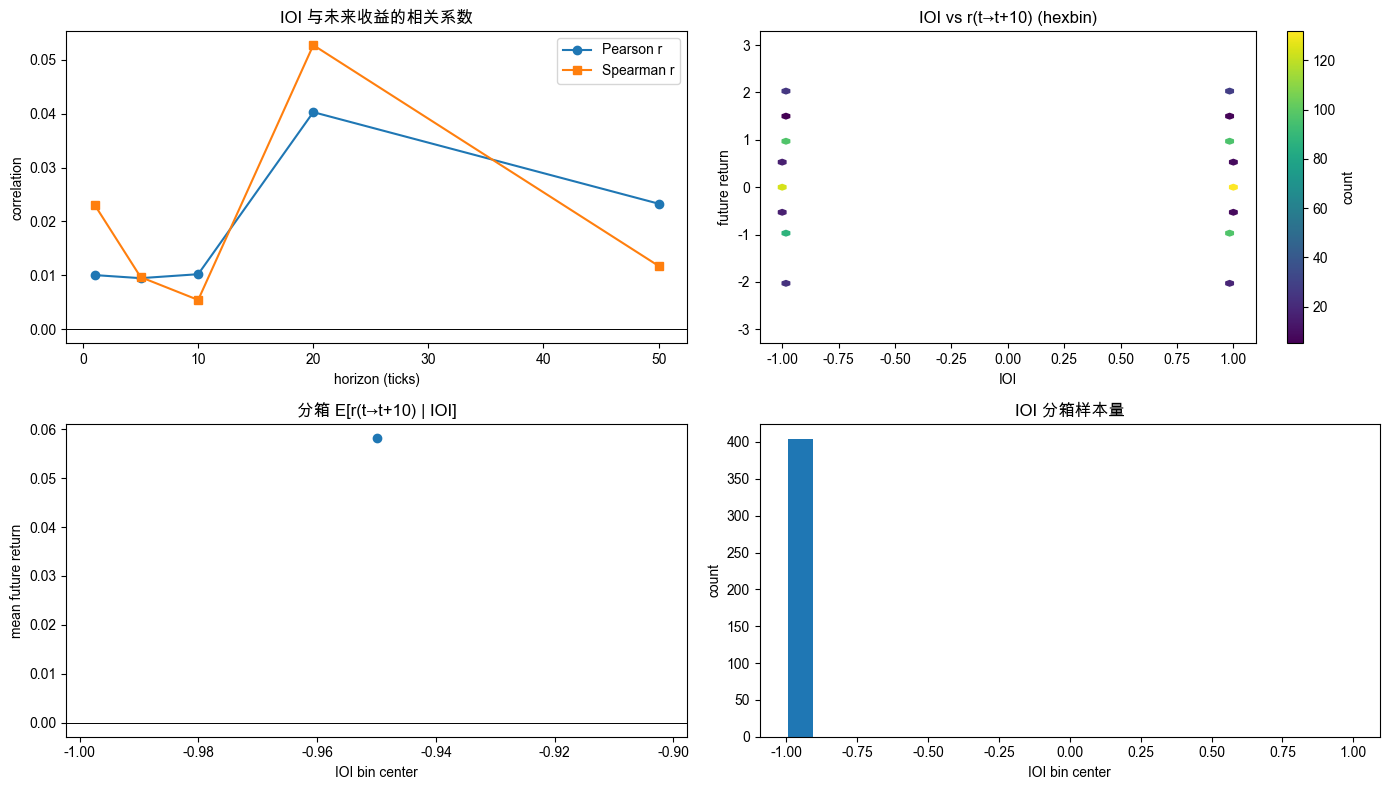


显著性摘要 (p<0.05):
h= 1: Pearson r=+0.0101 (p=0.776), Spearman r=+0.0231 (p=0.513)
h= 5: Pearson r=+0.0095 (p=0.788), Spearman r=+0.0097 (p=0.784)
h=10: Pearson r=+0.0102 (p=0.772), Spearman r=+0.0054 (p=0.877)
h=20: Pearson r=+0.0403 (p=0.254), Spearman r=+0.0527 (p=0.135)
h=50: Pearson r=+0.0233 (p=0.51), Spearman r=+0.0118 (p=0.739)


In [14]:
import pandas as pd
from scipy.stats import pearsonr, spearmanr

# 1) 取数据并构造非理性订单流
book_cols = [
    'inner_fair',
    'bid_price_1', 'bid_volume_1', 'bid_price_2', 'bid_volume_2', 'bid_price_3', 'bid_volume_3',
    'ask_price_1', 'ask_volume_1', 'ask_price_2', 'ask_volume_2', 'ask_price_3', 'ask_volume_3',
]
pdf_i = fair.select(book_cols).to_pandas().reset_index(drop=True)

fair_px = pdf_i['inner_fair'].astype(float)

irr_buy = np.zeros(len(pdf_i), dtype=float)
irr_sell = np.zeros(len(pdf_i), dtype=float)

for lvl in [1, 2, 3]:
    bp = pdf_i[f'bid_price_{lvl}'].astype(float)
    bv = np.abs(pdf_i[f'bid_volume_{lvl}'].astype(float))
    ap = pdf_i[f'ask_price_{lvl}'].astype(float)
    av = np.abs(pdf_i[f'ask_volume_{lvl}'].astype(float))

    irr_buy += np.where(bp > fair_px, bv, 0.0)
    irr_sell += np.where(ap < fair_px, av, 0.0)

denom = irr_buy + irr_sell
ioi = np.where(denom > 0, (irr_buy - irr_sell) / denom, np.nan)

print(f'有效 IOI 样本占比: {np.isfinite(ioi).mean():.4f}')
print(f'IOI mean={np.nanmean(ioi):.4f}, std={np.nanstd(ioi):.4f}')

# 2) 多 horizon 相关性检验
horizons = [1, 5, 10, 20, 50]
rows = []

for h in horizons:
    fut_ret = fair_px.shift(-h) - fair_px
    m = np.isfinite(ioi) & np.isfinite(fut_ret.to_numpy())
    x = ioi[m]
    y = fut_ret.to_numpy()[m]

    pr, pp = pearsonr(x, y)
    sr, sp = spearmanr(x, y)

    rows.append({
        'h': h,
        'n': int(m.sum()),
        'pearson_r': pr,
        'pearson_p': pp,
        'spearman_r': sr,
        'spearman_p': sp,
        'beta_ols': np.polyfit(x, y, 1)[0],
        'ret_mean': y.mean(),
    })

corr_tbl = pd.DataFrame(rows)
print(corr_tbl)

# 3) 画图
h_show = 10
ret_show = (fair_px.shift(-h_show) - fair_px).to_numpy()
m_show = np.isfinite(ioi) & np.isfinite(ret_show)
x = ioi[m_show]
y = ret_show[m_show]

# 分箱均值
bins = np.linspace(-1, 1, 21)
bin_id = np.digitize(x, bins) - 1
centers = (bins[:-1] + bins[1:]) / 2
y_mean = np.full(len(centers), np.nan)
y_cnt = np.zeros(len(centers), dtype=int)
for i in range(len(centers)):
    sel = bin_id == i
    y_cnt[i] = sel.sum()
    if y_cnt[i] > 30:
        y_mean[i] = y[sel].mean()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# 图1: 相关系数随 horizon
axes[0, 0].plot(corr_tbl['h'], corr_tbl['pearson_r'], marker='o', label='Pearson r')
axes[0, 0].plot(corr_tbl['h'], corr_tbl['spearman_r'], marker='s', label='Spearman r')
axes[0, 0].axhline(0, color='k', lw=0.7)
axes[0, 0].set_title('IOI 与未来收益的相关系数')
axes[0, 0].set_xlabel('horizon (ticks)')
axes[0, 0].set_ylabel('correlation')
axes[0, 0].legend()

# 图2: IOI vs future return 散点密度
hb = axes[0, 1].hexbin(x, y, gridsize=60, mincnt=5, cmap='viridis')
axes[0, 1].set_title(f'IOI vs r(t→t+{h_show}) (hexbin)')
axes[0, 1].set_xlabel('IOI')
axes[0, 1].set_ylabel('future return')
fig.colorbar(hb, ax=axes[0, 1], label='count')

# 图3: 分箱均值曲线
axes[1, 0].plot(centers, y_mean, marker='o')
axes[1, 0].axhline(0, color='k', lw=0.7)
axes[1, 0].set_title(f'分箱 E[r(t→t+{h_show}) | IOI]')
axes[1, 0].set_xlabel('IOI bin center')
axes[1, 0].set_ylabel('mean future return')

# 图4: 分箱样本量
axes[1, 1].bar(centers, y_cnt, width=(centers[1] - centers[0]) * 0.9)
axes[1, 1].set_title('IOI 分箱样本量')
axes[1, 1].set_xlabel('IOI bin center')
axes[1, 1].set_ylabel('count')

plt.tight_layout()
plt.show()

print('\n显著性摘要 (p<0.05):')
for _, r0 in corr_tbl.iterrows():
    print(f"h={int(r0['h']):>2}: Pearson r={r0['pearson_r']:+.4f} (p={r0['pearson_p']:.3g}), "
          f"Spearman r={r0['spearman_r']:+.4f} (p={r0['spearman_p']:.3g})")

    h      n  pearson_r_cont  pearson_p_cont
0   1  29950        0.001271        0.825957
1   5  29946        0.001441        0.803152
2  10  29941        0.004289        0.458018
3  20  29931        0.010007        0.083402
4  50  29901        0.008132        0.159674
h=10: mean ret | IOI=-1: 0.0582 +/- 0.1042 (n=404)
h=10: mean ret | IOI=+1: 0.0798 +/- 0.1028 (n=401)


/var/folders/zz/86sywqns5xbc6g80s01q5l0c0000gn/T/ipykernel_72362/3311080662.py:10: RuntimeWarning: invalid value encountered in divide
  ioi_cont = np.where(total_depth > 0, (irr_buy - irr_sell) / total_depth, np.nan)


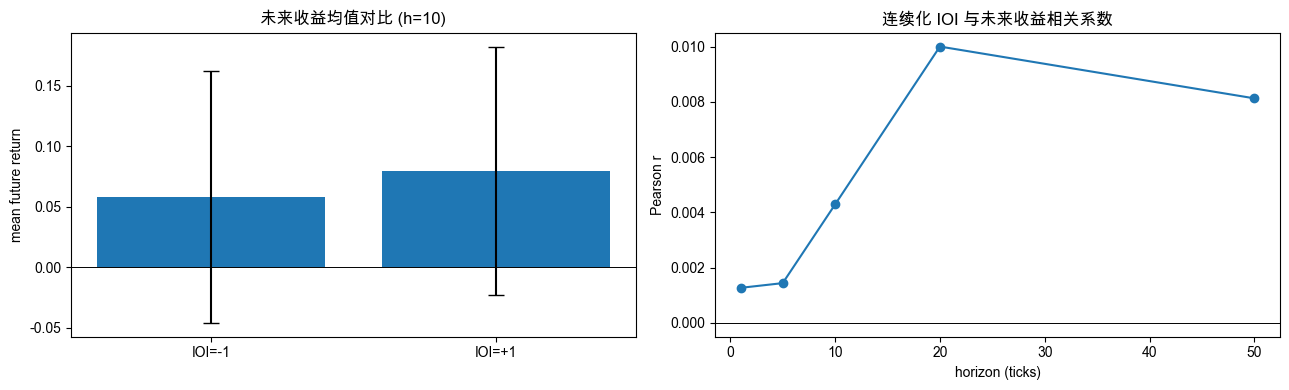

In [15]:
# 二元 IOI（严格定义）其实近似 sign 变量
ioi_bin = np.where(np.isfinite(ioi), np.sign(ioi), np.nan)

# 连续化替代：用总深度归一化净非理性流
total_depth = np.zeros(len(pdf_i), dtype=float)
for lvl in [1, 2, 3]:
    bv = np.nan_to_num(np.abs(pdf_i[f'bid_volume_{lvl}'].astype(float).to_numpy()), nan=0.0)
    av = np.nan_to_num(np.abs(pdf_i[f'ask_volume_{lvl}'].astype(float).to_numpy()), nan=0.0)
    total_depth += bv + av
ioi_cont = np.where(total_depth > 0, (irr_buy - irr_sell) / total_depth, np.nan)

horizons = [1, 5, 10, 20, 50]
rows2 = []
for h in horizons:
    fut_ret = (fair_px.shift(-h) - fair_px).to_numpy()
    m = np.isfinite(ioi_cont) & np.isfinite(fut_ret)
    x = ioi_cont[m]
    y = fut_ret[m]
    if len(x) >= 2:
        pr, pp = pearsonr(x, y)
    else:
        pr, pp = np.nan, np.nan
    rows2.append({'h': h, 'n': int(m.sum()), 'pearson_r_cont': pr, 'pearson_p_cont': pp})

corr_cont_tbl = pd.DataFrame(rows2)
print(corr_cont_tbl)

# 以 h=10 展示严格二元分组均值差
h_show = 10
ret_h = (fair_px.shift(-h_show) - fair_px).to_numpy()
m2 = np.isfinite(ioi_bin) & np.isfinite(ret_h)
xb = ioi_bin[m2]
yb = ret_h[m2]

g_neg = yb[xb < 0]
g_pos = yb[xb > 0]

def mean_ci(x):
    if len(x) < 2:
        return np.nan, np.nan
    m = np.mean(x)
    se = np.std(x, ddof=1) / np.sqrt(len(x))
    return m, 1.96 * se

m_neg, ci_neg = mean_ci(g_neg)
m_pos, ci_pos = mean_ci(g_pos)

print(f'h={h_show}: mean ret | IOI=-1: {m_neg:.4f} +/- {ci_neg:.4f} (n={len(g_neg)})')
print(f'h={h_show}: mean ret | IOI=+1: {m_pos:.4f} +/- {ci_pos:.4f} (n={len(g_pos)})')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 图A: 二元组均值+CI
axes[0].bar(['IOI=-1', 'IOI=+1'], [m_neg, m_pos], yerr=[ci_neg, ci_pos], capsize=6)
axes[0].axhline(0, color='k', lw=0.7)
axes[0].set_title(f'未来收益均值对比 (h={h_show})')
axes[0].set_ylabel('mean future return')

# 图B: 连续化 IOI 的相关系数随 horizon
axes[1].plot(corr_cont_tbl['h'], corr_cont_tbl['pearson_r_cont'], marker='o')
axes[1].axhline(0, color='k', lw=0.7)
axes[1].set_title('连续化 IOI 与未来收益相关系数')
axes[1].set_xlabel('horizon (ticks)')
axes[1].set_ylabel('Pearson r')

plt.tight_layout()
plt.show()

### 12.1 结果解释增强：二元 IOI 与连续化 IOI

上面的输出显示 `IOI` 几乎只取 `-1/+1`（因为严格跨 fair 时通常只会有单侧跨越），因此：

- `IOI` 更像二元分组变量，不适合做密集连续分箱散点解释；
- 增加两类图：
  - 二元组均值比较：`IOI=-1` vs `IOI=+1` 的未来收益；
  - 连续化指标：用总深度归一化的净非理性流，避免退化。

## 13. 窗口版非理性不平衡（不除以总深度）

按你的要求，改为维护时间窗口内的不平衡：

- 窗口净非理性流（主信号）：

$$
NI_t^{(W)}=\sum_{j=t-W+1}^{t}\left(V^{irr,buy}_j-V^{irr,sell}_j\right)
$$

- 窗口相对不平衡（可选，仅用非理性流做分母，不用总深度）：

$$
RI_t^{(W)}=\frac{\sum_{j=t-W+1}^{t}(V^{irr,buy}_j-V^{irr,sell}_j)}{\sum_{j=t-W+1}^{t}(V^{irr,buy}_j+V^{irr,sell}_j)}
$$

其中分母为 0 时记缺失。下面检验它们与未来收益的相关性。

      W   h  n_net  pearson_net     p_net  n_rel  pearson_rel     p_rel
0    20   1  29980     0.005568  0.335023  12807     0.007435  0.400184
1    20   5  29976     0.012708  0.027791  12807     0.014062  0.111539
2    20  10  29971     0.016371  0.004595  12807     0.023699  0.007318
3    20  20  29961     0.024333  0.000025  12797     0.039133  0.000010
4    20  50  29931     0.023772  0.000039  12777     0.035711  0.000054
5    50   1  29950     0.003625  0.530492  22493     0.002185  0.743109
6    50   5  29946     0.012032  0.037328  22489     0.009398  0.158763
7    50  10  29941     0.017494  0.002469  22484     0.014323  0.031744
8    50  20  29931     0.022924  0.000073  22474     0.017290  0.009540
9    50  50  29901     0.013759  0.017347  22444    -0.008648  0.195131
10  100   1  29900     0.001376  0.812005  27900    -0.000841  0.888239
11  100   5  29896     0.003451  0.550736  27896    -0.000344  0.954133
12  100  10  29891     0.007689  0.183769  27891     0.003557  0

/var/folders/zz/86sywqns5xbc6g80s01q5l0c0000gn/T/ipykernel_72362/2848549724.py:12: RuntimeWarning: invalid value encountered in divide
  rel_w = np.where(gross_w > 0, net_w / gross_w, np.nan)


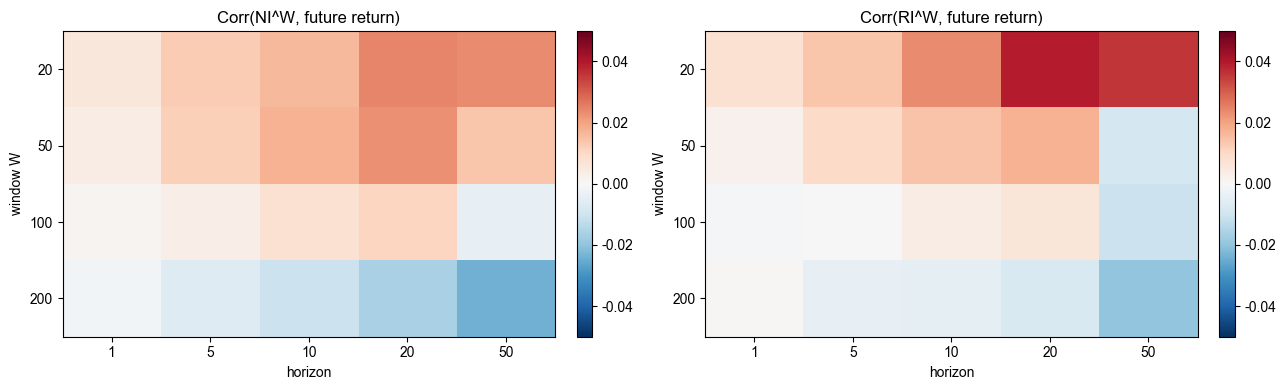

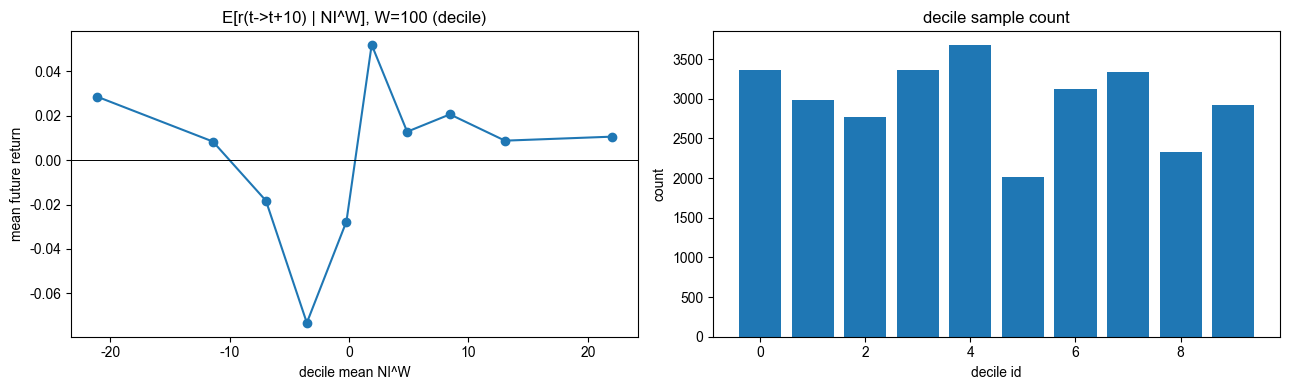


显著结果 (p_net < 0.05 或 p_rel < 0.05):
      W   h  n_net  pearson_net     p_net  n_rel  pearson_rel     p_rel
1    20   5  29976     0.012708  0.027791  12807     0.014062  0.111539
2    20  10  29971     0.016371  0.004595  12807     0.023699  0.007318
3    20  20  29961     0.024333  0.000025  12797     0.039133  0.000010
4    20  50  29931     0.023772  0.000039  12777     0.035711  0.000054
6    50   5  29946     0.012032  0.037328  22489     0.009398  0.158763
7    50  10  29941     0.017494  0.002469  22484     0.014323  0.031744
8    50  20  29931     0.022924  0.000073  22474     0.017290  0.009540
9    50  50  29901     0.013759  0.017347  22444    -0.008648  0.195131
18  200  20  29781    -0.016145  0.005334  29649    -0.007800  0.179275
19  200  50  29751    -0.023839  0.000039  29619    -0.019569  0.000757


In [16]:
# 需要上一个单元已经构造 irr_buy, irr_sell, fair_px
net_irr = irr_buy - irr_sell
gross_irr = irr_buy + irr_sell

window_list = [20, 50, 100, 200]
horizons = [1, 5, 10, 20, 50]

rows_w = []
for W in window_list:
    net_w = pd.Series(net_irr).rolling(W, min_periods=W).sum().to_numpy()
    gross_w = pd.Series(gross_irr).rolling(W, min_periods=W).sum().to_numpy()
    rel_w = np.where(gross_w > 0, net_w / gross_w, np.nan)

    for h in horizons:
        fut_ret = (fair_px.shift(-h) - fair_px).to_numpy()

        # 主信号: 窗口净非理性流
        m1 = np.isfinite(net_w) & np.isfinite(fut_ret)
        x1 = net_w[m1]
        y1 = fut_ret[m1]
        r1, p1 = pearsonr(x1, y1) if len(x1) >= 2 else (np.nan, np.nan)

        # 可选信号: 窗口相对不平衡（仅非理性分母）
        m2 = np.isfinite(rel_w) & np.isfinite(fut_ret)
        x2 = rel_w[m2]
        y2 = fut_ret[m2]
        r2, p2 = pearsonr(x2, y2) if len(x2) >= 2 else (np.nan, np.nan)

        rows_w.append({
            'W': W,
            'h': h,
            'n_net': int(m1.sum()),
            'pearson_net': r1,
            'p_net': p1,
            'n_rel': int(m2.sum()),
            'pearson_rel': r2,
            'p_rel': p2,
        })

win_tbl = pd.DataFrame(rows_w)
print(win_tbl)

# 可视化: 热力图 + 指定窗口分组图
pivot_net = win_tbl.pivot(index='W', columns='h', values='pearson_net')
pivot_rel = win_tbl.pivot(index='W', columns='h', values='pearson_rel')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
im0 = axes[0].imshow(pivot_net.values, aspect='auto', cmap='RdBu_r', vmin=-0.05, vmax=0.05)
axes[0].set_title('Corr(NI^W, future return)')
axes[0].set_xticks(range(len(pivot_net.columns))); axes[0].set_xticklabels(pivot_net.columns)
axes[0].set_yticks(range(len(pivot_net.index))); axes[0].set_yticklabels(pivot_net.index)
axes[0].set_xlabel('horizon'); axes[0].set_ylabel('window W')
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(pivot_rel.values, aspect='auto', cmap='RdBu_r', vmin=-0.05, vmax=0.05)
axes[1].set_title('Corr(RI^W, future return)')
axes[1].set_xticks(range(len(pivot_rel.columns))); axes[1].set_xticklabels(pivot_rel.columns)
axes[1].set_yticks(range(len(pivot_rel.index))); axes[1].set_yticklabels(pivot_rel.index)
axes[1].set_xlabel('horizon'); axes[1].set_ylabel('window W')
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# 展示一个窗口下的单调性（W=100, h=10）
W_show, h_show = 100, 10
net_w = pd.Series(net_irr).rolling(W_show, min_periods=W_show).sum().to_numpy()
fut_ret = (fair_px.shift(-h_show) - fair_px).to_numpy()
mask = np.isfinite(net_w) & np.isfinite(fut_ret)

x = net_w[mask]
y = fut_ret[mask]
q = pd.qcut(x, 10, duplicates='drop')
g = pd.DataFrame({'x': x, 'y': y, 'q': q}).groupby('q', observed=False).agg(x_mean=('x', 'mean'), y_mean=('y', 'mean'), n=('y', 'size')).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(g['x_mean'], g['y_mean'], marker='o')
axes[0].axhline(0, color='k', lw=0.7)
axes[0].set_title(f'E[r(t->t+{h_show}) | NI^W], W={W_show} (decile)')
axes[0].set_xlabel('decile mean NI^W')
axes[0].set_ylabel('mean future return')

axes[1].bar(range(len(g)), g['n'])
axes[1].set_title('decile sample count')
axes[1].set_xlabel('decile id')
axes[1].set_ylabel('count')

plt.tight_layout()
plt.show()

print('\n显著结果 (p_net < 0.05 或 p_rel < 0.05):')
sig = win_tbl[(win_tbl['p_net'] < 0.05) | (win_tbl['p_rel'] < 0.05)]
print(sig if len(sig) else '无显著项')

## 14. 结果汇总表（符号说明 + 数值结果）

### 14.1 符号说明

下表统一说明本节出现的符号。

In [17]:
# 符号说明表
symbol_rows = [
    {'symbol': 'fair_t', 'meaning': 't 时刻 fair price（本实验使用 inner_fair）', 'unit': 'price'},
    {'symbol': 'bp_{t,i}', 'meaning': 't 时刻 bid 第 i 档价格（i=1,2,3）', 'unit': 'price'},
    {'symbol': 'ap_{t,i}', 'meaning': 't 时刻 ask 第 i 档价格（i=1,2,3）', 'unit': 'price'},
    {'symbol': 'bv_{t,i}', 'meaning': 't 时刻 bid 第 i 档挂单量绝对值', 'unit': 'volume'},
    {'symbol': 'av_{t,i}', 'meaning': 't 时刻 ask 第 i 档挂单量绝对值', 'unit': 'volume'},
    {'symbol': 'V^{irr,buy}_t', 'meaning': '非理性买单量，满足 bp_{t,i} > fair_t 的量之和', 'unit': 'volume'},
    {'symbol': 'V^{irr,sell}_t', 'meaning': '非理性卖单量，满足 ap_{t,i} < fair_t 的量之和', 'unit': 'volume'},
    {'symbol': 'IOI_t', 'meaning': '(V^{irr,buy}_t - V^{irr,sell}_t) / (V^{irr,buy}_t + V^{irr,sell}_t)', 'unit': 'dimensionless'},
    {'symbol': 'NI_t^{(W)}', 'meaning': '窗口净非理性流，sum_{j=t-W+1..t}(V^{irr,buy}_j - V^{irr,sell}_j)', 'unit': 'volume'},
    {'symbol': 'RI_t^{(W)}', 'meaning': '窗口相对不平衡，sum(net)/sum(gross)（gross 为非理性买卖总和）', 'unit': 'dimensionless'},
    {'symbol': 'r_{t->t+h}', 'meaning': '未来收益，fair_{t+h} - fair_t', 'unit': 'price'},
    {'symbol': 'W', 'meaning': '滚动窗口长度（tick）', 'unit': 'tick'},
    {'symbol': 'h', 'meaning': '预测 horizon（tick）', 'unit': 'tick'},
    {'symbol': 'Pearson r', 'meaning': '线性相关系数 corr(x, y)', 'unit': 'dimensionless'},
    {'symbol': 'p-value', 'meaning': 'Pearson 相关系数对应显著性检验 p 值', 'unit': 'dimensionless'},
    {'symbol': 'n', 'meaning': '用于该统计量的有效样本数', 'unit': 'count'},
]

symbol_df = pd.DataFrame(symbol_rows)
print('符号说明表')
print(symbol_df.to_string(index=False))

# 结果表 1: 严格 IOI vs future return（来自 corr_tbl）
if 'corr_tbl' in globals():
    t1 = corr_tbl.copy()
    t1 = t1.rename(columns={
        'h': 'horizon_h',
        'n': 'n',
        'pearson_r': 'pearson_r_IOI',
        'pearson_p': 'p_IOI',
        'spearman_r': 'spearman_r_IOI',
        'spearman_p': 'p_spearman_IOI',
        'beta_ols': 'beta_ols_IOI',
        'ret_mean': 'mean_future_return',
    })
    for c in ['pearson_r_IOI', 'p_IOI', 'spearman_r_IOI', 'p_spearman_IOI', 'beta_ols_IOI', 'mean_future_return']:
        t1[c] = t1[c].astype(float).round(6)
    print('\n结果表 1: 严格 IOI 与未来收益')
    print(t1.sort_values('horizon_h').reset_index(drop=True).to_string(index=False))

# 结果表 2: 窗口 NI^W / RI^W vs future return（来自 win_tbl）
if 'win_tbl' in globals():
    t2 = win_tbl.copy()
    t2 = t2.rename(columns={
        'W': 'window_W',
        'h': 'horizon_h',
        'n_net': 'n_NI',
        'pearson_net': 'pearson_r_NI',
        'p_net': 'p_NI',
        'n_rel': 'n_RI',
        'pearson_rel': 'pearson_r_RI',
        'p_rel': 'p_RI',
    })
    for c in ['pearson_r_NI', 'p_NI', 'pearson_r_RI', 'p_RI']:
        t2[c] = t2[c].astype(float).round(6)
    print('\n结果表 2: 窗口不平衡与未来收益')
    print(t2.sort_values(['window_W', 'horizon_h']).reset_index(drop=True).to_string(index=False))

# 结果表 3: 窗口不平衡透视（便于横向阅读）
if 'win_tbl' in globals():
    pvt_r = win_tbl.pivot(index='W', columns='h', values='pearson_net').round(6)
    pvt_p = win_tbl.pivot(index='W', columns='h', values='p_net').round(6)
    print('\n结果表 3A: Pearson r of NI^W (行=W, 列=h)')
    print(pvt_r.to_string())
    print('\n结果表 3B: p-value of NI^W (行=W, 列=h)')
    print(pvt_p.to_string())

符号说明表
        symbol                                                             meaning          unit
        fair_t                                   t 时刻 fair price（本实验使用 inner_fair）         price
      bp_{t,i}                                           t 时刻 bid 第 i 档价格（i=1,2,3）         price
      ap_{t,i}                                           t 时刻 ask 第 i 档价格（i=1,2,3）         price
      bv_{t,i}                                                t 时刻 bid 第 i 档挂单量绝对值        volume
      av_{t,i}                                                t 时刻 ask 第 i 档挂单量绝对值        volume
 V^{irr,buy}_t                                    非理性买单量，满足 bp_{t,i} > fair_t 的量之和        volume
V^{irr,sell}_t                                    非理性卖单量，满足 ap_{t,i} < fair_t 的量之和        volume
         IOI_t (V^{irr,buy}_t - V^{irr,sell}_t) / (V^{irr,buy}_t + V^{irr,sell}_t) dimensionless
    NI_t^{(W)}            窗口净非理性流，sum_{j=t-W+1..t}(V^{irr,buy}_j - V^{irr,sell}_j)        volume
    RI_t^{(W)}          

## Mean Reversion 参数整理（用于实盘/回测）

### 1) 采用的离散 OU 形式（每个 tick）

\[
p_{t+1}-\mu=(1-\theta)(p_t-\mu)+\varepsilon_t,\quad \varepsilon_t\sim\mathcal N(0,\sigma_\varepsilon^2)
\]

等价写法：

\[
\Delta p_t=-\theta(p_t-\mu)+\varepsilon_t
\]

### 2) 本次估计参数（ASH inner_fair）

- \(\mu = 10000\)
- \(\hat\theta\)（drift 回归）= **0.00415**
- \(\theta_{acf}\)（ACF 估计）= **0.00423**
- \(\sigma_\varepsilon\)（残差波动）= **0.4300**
- \(\sigma_p\) 观测（样本稳态波动）= **4.6935**
- \(\sigma_p\) 理论（OU 推导）= **4.7227**
- \(\sigma_{\Delta p}\)（单步变化）= **0.4304**

### 3) 直接可用于均值回归策略的派生量

- AR(1) 系数：\(\phi=1-\theta\approx 0.99585\)
- 半衰期（tick）：

\[
\tau_{1/2}=\frac{\ln 2}{\theta}\approx \frac{0.693}{0.00415}\approx 167\ \text{ticks}
\]

- 标准化偏离（建议用观测 \(\sigma_p\)）：

\[
z_t=\frac{p_t-\mu}{\sigma_p},\quad \sigma_p\approx 4.6935
\]

### 4) 策略落地建议（参数口径）

- 均值：用 \(\mu=10000\)
- 回归速度：优先用 \(\theta=0.00415\)，ACF 结果可作稳健性对照
- 噪声：用 \(\sigma_\varepsilon=0.43\) 做一步预测带宽
- 偏离尺度：用 \(\sigma_p\) 观测值 4.6935 做 z-score（比理论值更贴样本）

### 5) 一步预测（可直接写进信号）

\[
\mathbb E[p_{t+1}\mid p_t]=\mu+(1-\theta)(p_t-\mu)
\]

\[
\mathbb Var[p_{t+1}\mid p_t]=\sigma_\varepsilon^2
\]

可把期望回归量写成：

\[
\mathbb E[\Delta p_t\mid p_t]=-\theta(p_t-\mu)
\]

用于决定做多/做空方向与强度。